In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pandas


1 Create a Pandas DataFrame for 5 students with their Name, Age, and Marks.

Display the DataFrame.

Show the basic statistics summary of the data.

Filter and display the students who scored more than 80 marks.

Sort the students by marks in descending order.

In [20]:
#1
# ----------- 1. Create Data using Dictionary and Convert to DataFrame -----------
data = {
    "Name": ["Maulik", "Nitish", "Yash", "Ashmit", "Kushagra"],
    "Age": [20, 22, 19, 21, 20],
    "Marks": [85, 70, 90, 60, 95]
}

df = pd.DataFrame(data)
print("\n--- DataFrame ---")
print(df)

# ----------- 2. Describe the Data (Basic Statistics) -----------
print("\n--- Data Summary ---")
print(df.describe())

# ----------- 3. Filter: Students who scored above 80 -----------
print("\n--- Students with Marks > 80 ---")
print(df[df["Marks"] > 80])

# ----------- 4. Sort by Marks (Descending) -----------
sorted_df = df.sort_values(by="Marks", ascending=False)
print("\n--- Sorted by Marks (High to Low) ---")
print(sorted_df)




--- DataFrame ---
       Name  Age  Marks
0    Maulik   20     85
1    Nitish   22     70
2      Yash   19     90
3    Ashmit   21     60
4  Kushagra   20     95

--- Data Summary ---
             Age     Marks
count   5.000000   5.00000
mean   20.400000  80.00000
std     1.140175  14.57738
min    19.000000  60.00000
25%    20.000000  70.00000
50%    20.000000  85.00000
75%    21.000000  90.00000
max    22.000000  95.00000

--- Students with Marks > 80 ---
       Name  Age  Marks
0    Maulik   20     85
2      Yash   19     90
4  Kushagra   20     95

--- Sorted by Marks (High to Low) ---
       Name  Age  Marks
4  Kushagra   20     95
2      Yash   19     90
0    Maulik   20     85
1    Nitish   22     70
3    Ashmit   21     60


2 You have a DataFrame df with a column "salary". Write Pandas code to normalize the salary values between 0 and 1.

In [21]:
df = pd.DataFrame({"salary": [3000, 5000, 7000, 10000, 15000]})

# Formula: (x - min) / (max - min)
df["normalized_salary"] = (df["salary"] - df["salary"].min()) / (df["salary"].max() - df["salary"].min())

print(df)

   salary  normalized_salary
0    3000           0.000000
1    5000           0.166667
2    7000           0.333333
3   10000           0.583333
4   15000           1.000000


3 Given a DataFrame with columns ["department", "employee", "salary"], how would you find the second-highest salary in each department?

In [22]:
df = pd.DataFrame({
    "department": ["HR", "HR", "IT", "IT", "Sales", "Sales"],
    "employee": ["A", "B", "C", "D", "E", "F"],
    "salary": [40000, 50000, 60000, 70000, 30000, 35000]
})

# Sort salaries within each department, then rank
df["rank"] = df.groupby("department")["salary"].rank(method="dense", ascending=False)

# Pick only rows with rank = 2 (second highest)
second_highest = df[df["rank"] == 2]

print(second_highest)

  department employee  salary  rank
0         HR        A   40000   2.0
2         IT        C   60000   2.0
4      Sales        E   30000   2.0


4 Suppose you have a DataFrame df with missing values. How would you fill missing values in column "age" with the median age, but keep other columns unchanged?

In [23]:
df = pd.DataFrame({"name": ["A", "B", "C", "D"],
                "age": [25, np.nan, 30, np.nan],
                "city": ["Delhi", "Mumbai", "Chennai", "Kolkata"]})

# Fill 'age' column with its median
df["age"].fillna(df["age"].median(), inplace=True)

print(df)

  name   age     city
0    A  25.0    Delhi
1    B  27.5   Mumbai
2    C  30.0  Chennai
3    D  27.5  Kolkata


C:\Users\mauli\AppData\Local\Temp\ipykernel_38556\2278793945.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


5   
    You have two DataFrames:

    df_orders(order_id, customer_id, amount)

    df_customers(customer_id, name)
    Write Pandas code to merge them so that all orders are preserved, but only matching customer details are included.

In [24]:
df_orders = pd.DataFrame({
    "order_id": [1, 2, 3],
    "customer_id": [101, 102, 103],
    "amount": [250, 450, 300]
})

df_customers = pd.DataFrame({
    "customer_id": [101, 103],
    "name": ["Alice", "Charlie"]
})

# Merge keeping all orders, and only matching customers
merged = pd.merge(df_orders, df_customers, on="customer_id", how="left")

print(merged)

   order_id  customer_id  amount     name
0         1          101     250    Alice
1         2          102     450      NaN
2         3          103     300  Charlie


6 Given a time series DataFrame with a "date" column, how would you resample it to monthly frequency and compute the mean of each month?

In [25]:
date_rng = pd.date_range(start="2023-01-01", end="2023-03-31", freq="D")
df = pd.DataFrame({"date": date_rng, "sales": np.random.randint(100, 500, size=len(date_rng))})

# Convert to datetime index for resampling
df.set_index("date", inplace=True)

# Resample monthly and take mean
monthly_avg = df.resample("M").mean()

print(monthly_avg)

                 sales
date                  
2023-01-31  284.451613
2023-02-28  265.250000
2023-03-31  291.290323


C:\Users\mauli\AppData\Local\Temp\ipykernel_38556\691409469.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample("M").mean()


7 Write Pandas code to select all rows from a DataFrame where the "name" column starts with the letter 'A' and "score" is greater than 80.

In [26]:
df = pd.DataFrame({
    "name": ["Aaryaman", "Maulik", "Ankit", "Mohit"],
    "score": [85, 72, 90, 65]
})

filtered = df[(df["name"].str.startswith("A")) & (df["score"] > 80)]

print(filtered)


       name  score
0  Aaryaman     85
2     Ankit     90


8 How would you pivot a DataFrame with columns ["city", "month", "temperature"] so that cities become rows, months become columns, and values are the temperature?

In [27]:
df = pd.DataFrame({
    "city": ["Delhi", "Delhi", "Mumbai", "Mumbai"],
    "month": ["Jan", "Feb", "Jan", "Feb"],
    "temperature": [15, 18, 25, 28]
})

# Pivot so cities are rows, months are columns
pivoted = df.pivot(index="city", columns="month", values="temperature")

print(pivoted)


month   Feb  Jan
city            
Delhi    18   15
Mumbai   28   25


9 You have a DataFrame df with a "category" column and "sales" column. Write Pandas code to compute the cumulative sum of sales within each category.

In [28]:
df = pd.DataFrame({
    "category": ["A", "A", "B", "B", "A"],
    "sales": [100, 200, 300, 400, 150]
})

# Group by category, then compute cumulative sum
df["cumulative_sales"] = df.groupby("category")["sales"].cumsum()

print(df)


  category  sales  cumulative_sales
0        A    100               100
1        A    200               300
2        B    300               300
3        B    400               700
4        A    150               450


10 Given a DataFrame with a "date" column in string format ("YYYY-MM-DD"), how do you convert it to datetime and extract a new column "weekday" containing the day of the week?

In [29]:
df = pd.DataFrame({"date": ["2023-01-01", "2023-01-02", "2023-01-03"]})

# Convert string to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract weekday name
df["weekday"] = df["date"].dt.day_name()

print(df)


        date  weekday
0 2023-01-01   Sunday
1 2023-01-02   Monday
2 2023-01-03  Tuesday


# Matplotlib

1 Create a line plot of sine and cosine on the same figure with custom line styles, add a legend outside the plot, and show gridlines only on the x-axis.

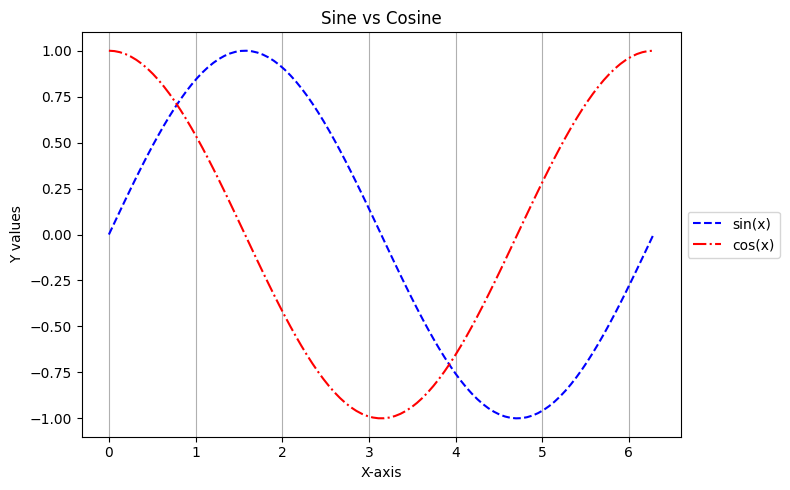

In [30]:
x = np.linspace(0, 2*np.pi, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8,5))
plt.plot(x, y1, linestyle="--", color="blue", label="sin(x)")
plt.plot(x, y2, linestyle="-.", color="red", label="cos(x)")

plt.title("Sine vs Cosine")
plt.xlabel("X-axis")
plt.ylabel("Y values")

# Legend outside the plot
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Grid only on x-axis
plt.grid(axis="x")

plt.tight_layout()
plt.show()


2 Plot a bar chart of student scores and annotate each bar with its value on top.

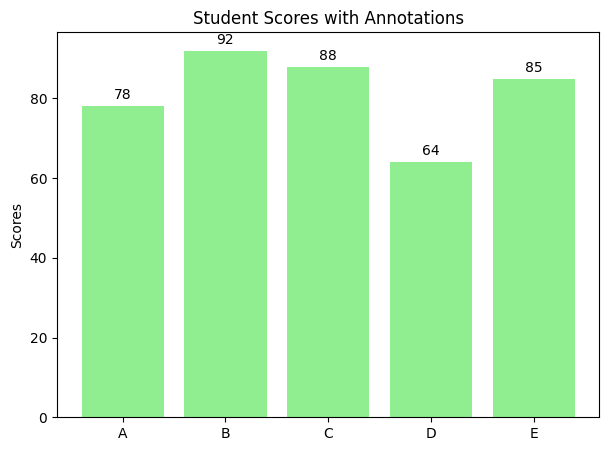

In [31]:
students = ["A", "B", "C", "D", "E"]
scores = [78, 92, 88, 64, 85]

plt.figure(figsize=(7,5))
bars = plt.bar(students, scores, color="lightgreen")

# Annotating values on top
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
            str(bar.get_height()), ha="center", va="bottom")

plt.title("Student Scores with Annotations")
plt.ylabel("Scores")
plt.show()


3 Create a scatter plot of random points, color them based on their distance from origin, and add a colorbar.

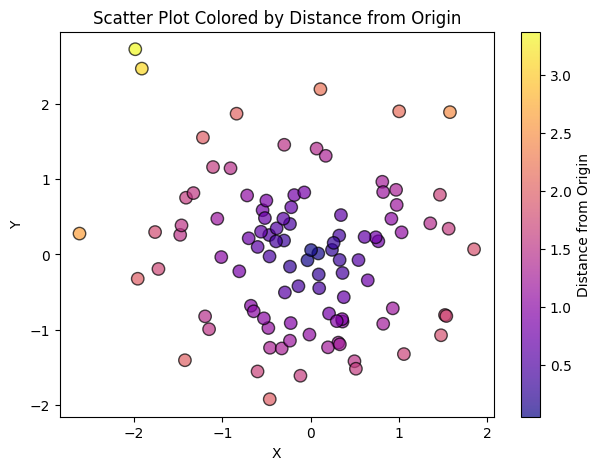

In [32]:
np.random.seed(42)
x = np.random.randn(100)
y = np.random.randn(100)

# Distance from origin
distance = np.sqrt(x**2 + y**2)

plt.figure(figsize=(7,5))
scatter = plt.scatter(x, y, c=distance, cmap="plasma", s=80, alpha=0.7, edgecolors="black")

plt.title("Scatter Plot Colored by Distance from Origin")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(scatter, label="Distance from Origin")
plt.show()


4 Plot a histogram of normally distributed data with 30 bins, and overlay a line plot of the cumulative distribution

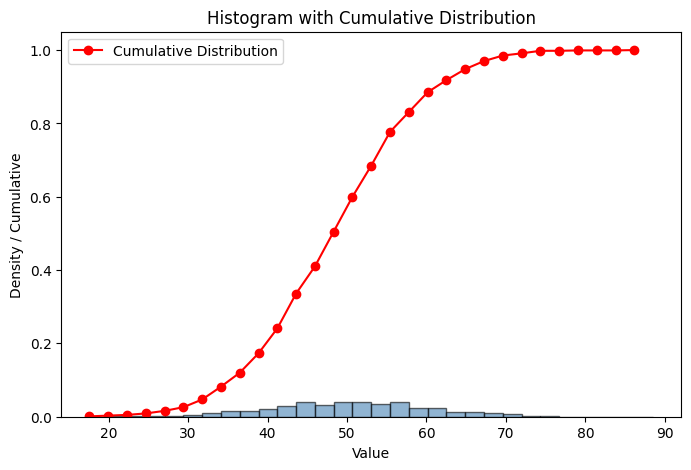

In [33]:
data = np.random.normal(loc=50, scale=10, size=1000)

plt.figure(figsize=(8,5))
# Histogram
counts, bins, patches = plt.hist(data, bins=30, density=True, alpha=0.6, color="steelblue", edgecolor="black")

# Cumulative distribution
cumulative = np.cumsum(counts) / np.sum(counts)
plt.plot(bins[:-1], cumulative, color="red", marker="o", label="Cumulative Distribution")

plt.title("Histogram with Cumulative Distribution")
plt.xlabel("Value")
plt.ylabel("Density / Cumulative")
plt.legend()
plt.show()


5 Create a pie chart with percentages, explode the largest slice, and display it in a donut chart style.

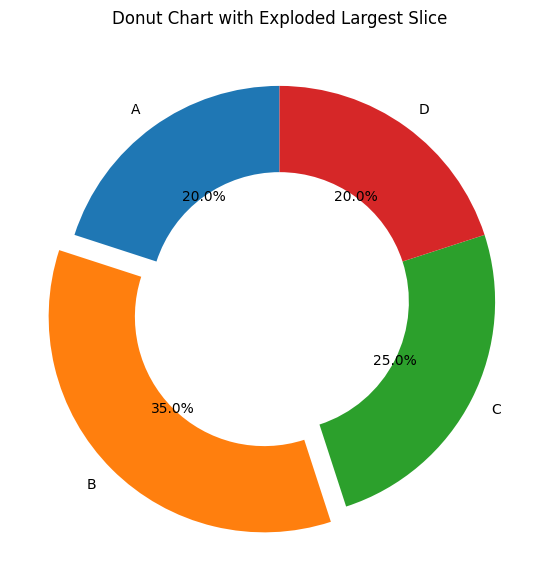

In [34]:
sizes = [20, 35, 25, 20]
labels = ["A", "B", "C", "D"]

# Find largest slice
largest = np.argmax(sizes)
explode = [0.1 if i == largest else 0 for i in range(len(sizes))]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", explode=explode, startangle=90, wedgeprops={"width":0.4})
plt.title("Donut Chart with Exploded Largest Slice")
plt.show()


6 Create a stacked bar chart showing sales of three products over four quarters.

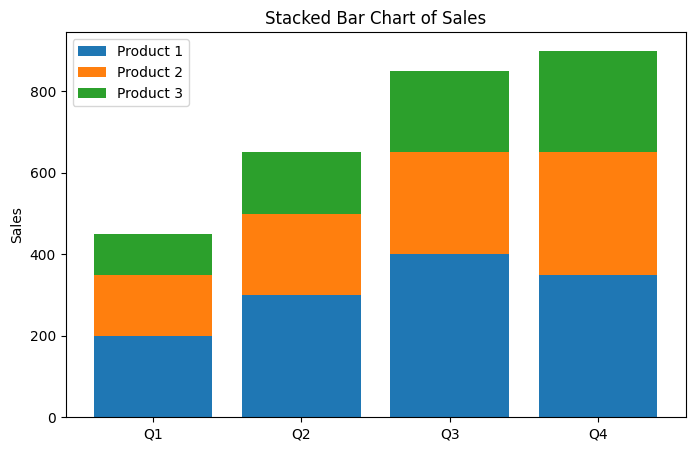

In [35]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
product1 = [200, 300, 400, 350]
product2 = [150, 200, 250, 300]
product3 = [100, 150, 200, 250]

plt.figure(figsize=(8,5))
plt.bar(quarters, product1, label="Product 1")
plt.bar(quarters, product2, bottom=product1, label="Product 2")
plt.bar(quarters, product3, bottom=np.array(product1)+np.array(product2), label="Product 3")

plt.title("Stacked Bar Chart of Sales")
plt.ylabel("Sales")
plt.legend()
plt.show()


7 Plot two y-axes: GDP on left axis and Inflation on right axis, both against years. 

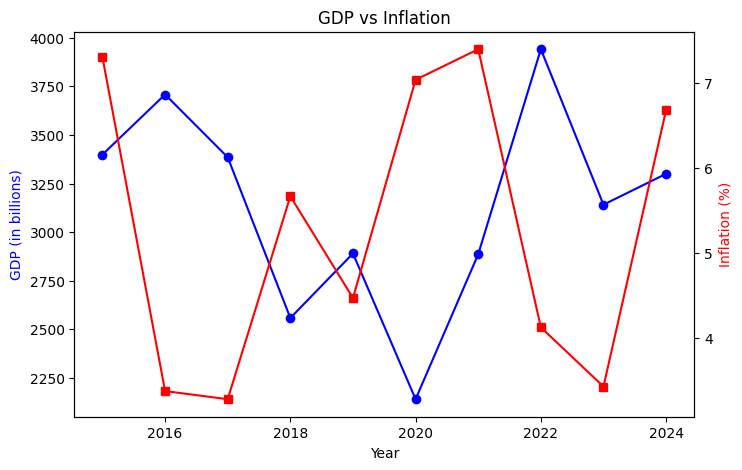

In [36]:
years = np.arange(2015, 2025)
gdp = np.random.randint(2000, 4000, size=len(years))
inflation = np.random.uniform(2, 8, size=len(years))

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(years, gdp, color="blue", marker="o")
ax1.set_xlabel("Year")
ax1.set_ylabel("GDP (in billions)", color="blue")

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(years, inflation, color="red", marker="s")
ax2.set_ylabel("Inflation (%)", color="red")

plt.title("GDP vs Inflation")
plt.show()


8 Plot a boxplot of exam scores across 4 subjects, and highlight outliers in red.

C:\Users\mauli\AppData\Local\Temp\ipykernel_38556\942942712.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(scores, labels=subjects, flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle="none"))


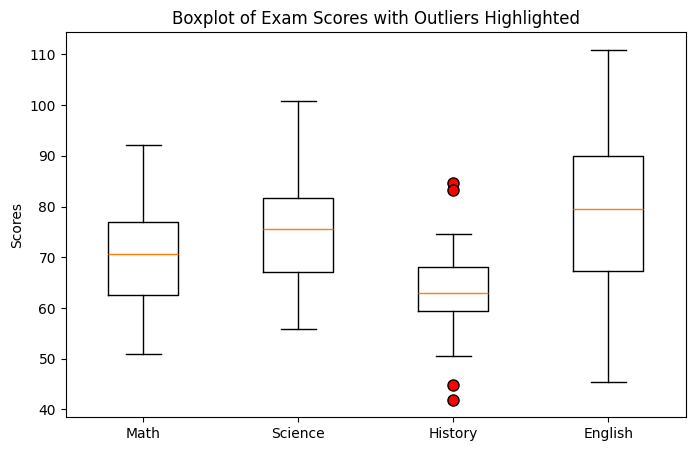

In [37]:
subjects = ["Math", "Science", "History", "English"]
scores = [np.random.normal(70, 10, 50),
        np.random.normal(75, 12, 50),
        np.random.normal(65, 8, 50),
        np.random.normal(80, 15, 50)]

plt.figure(figsize=(8,5))
plt.boxplot(scores, labels=subjects, flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle="none"))

plt.title("Boxplot of Exam Scores with Outliers Highlighted")
plt.ylabel("Scores")
plt.show()


9 Create a polar plot of r = sin(3θ) for θ from 0 to 2π.

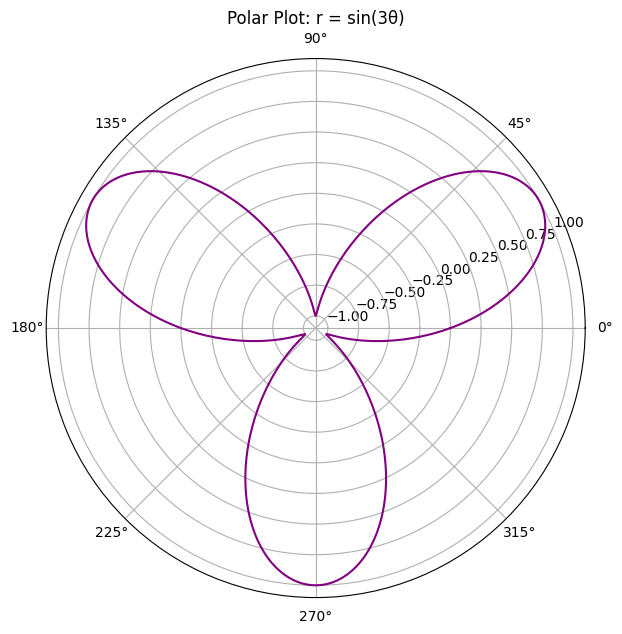

In [38]:
theta = np.linspace(0, 2*np.pi, 500)
r = np.sin(3*theta)

plt.figure(figsize=(7,7))
ax = plt.subplot(111, projection="polar")
ax.plot(theta, r, color="purple")

plt.title("Polar Plot: r = sin(3θ)")
plt.show()


10 Create a heatmap using imshow to visualize a correlation matrix of a random dataset (5x5).

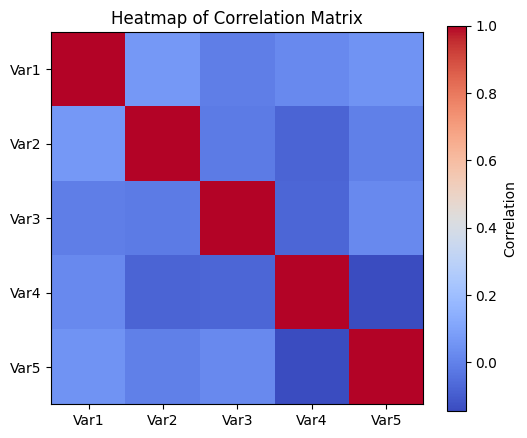

In [39]:
data = np.random.rand(100, 5)
corr_matrix = np.corrcoef(data, rowvar=False)

plt.figure(figsize=(6,5))
heatmap = plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(heatmap, label="Correlation")
plt.xticks(range(5), [f"Var{i+1}" for i in range(5)])
plt.yticks(range(5), [f"Var{i+1}" for i in range(5)])
plt.title("Heatmap of Correlation Matrix")
plt.show()
